# **Multiclass Diabetes Classification — BRFSS 2015 Health Indicators**
## **Final Project — Python for Machine Learning**

## Prepared By Md Sabid Hasan



This notebook implements the full pipeline:
1. Setup & data loading
2. Exploratory data analysis (histograms, boxplots, correlation heatmap, class distribution)
3. Pipeline diagram
4. Preprocessing (stratified split + StandardScaler)
5. Baseline models (class-weighted, no resampling)
6. SMOTE resampling + retraining
7. Hyperparameter tuning (GridSearchCV)
8. RBF-kernel SVC experiment on a stratified subsample
9. Final evaluation of tuned models (confusion matrices)
10. **Dual winners** — best by macro-F1 *and* best by overall accuracy
11. Learning curves (both winners)
12. XGBoost loss curve
13. ROC curves (both winners)
14. Feature importance — RF, XGBoost (with proper names), LinearSVC coefficients
15. SHAP analysis (XGBoost)
16. Stratified 5-fold CV
17. Per-class Precision / Recall / F1 comparison
18. Macro vs Weighted vs Accuracy comparison across all 12 configurations
19. Training vs Test confusion matrices for the two best models
20. Full summary table


## 0. Setup and Imports

In [1]:
!pip install xgboost imbalanced-learn shap


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# sklearn
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold,
    StratifiedShuffleSplit, cross_val_score, learning_curve
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_curve, auc, precision_score, recall_score,
    precision_recall_fscore_support
)

# Boosting
from xgboost import XGBClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Interpretability
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('shap not installed — SHAP section will be skipped. Install with: pip install shap')

# Display settings
pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Environment ready.')


Environment ready.


## 1. Data Loading and Initial Exploration

In [3]:
DATA_PATH = r'diabetes_012_health_indicators_BRFSS2015.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()


Shape: (253680, 22)
Columns: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
print('Missing values per column:')
print(df.isnull().sum().to_string())
print()
print('Data types:')
print(df.dtypes.to_string())


Missing values per column:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0

Data types:
Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyH

In [5]:
# Class distribution — the central challenge of the problem
class_counts = df['Diabetes_012'].value_counts().sort_index()
class_pct = df['Diabetes_012'].value_counts(normalize=True).sort_index() * 100
class_summary = pd.DataFrame({
    'Class': ['0 (No diabetes)', '1 (Prediabetes)', '2 (Diabetes)'],
    'Count': class_counts.values,
    'Percent': class_pct.round(2).values,
})
print(class_summary.to_string(index=False))


          Class  Count  Percent
0 (No diabetes) 213703    84.24
1 (Prediabetes)   4631     1.83
   2 (Diabetes)  35346    13.93


## 2. Exploratory Data Analysis

Five EDA views: summary statistics, feature histograms, boxplots for spread/outliers, correlation heatmap, and target class bar chart. These supply the EDA figures used in the report.

In [6]:
# Summary statistics
df.describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.297,0.698,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429,0.495,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424,0.494,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.963,0.190,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382,6.609,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443,0.497,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.041,0.197,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094,0.292,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.757,0.429,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634,0.482,0.0,0.0,1.0,1.0,1.0


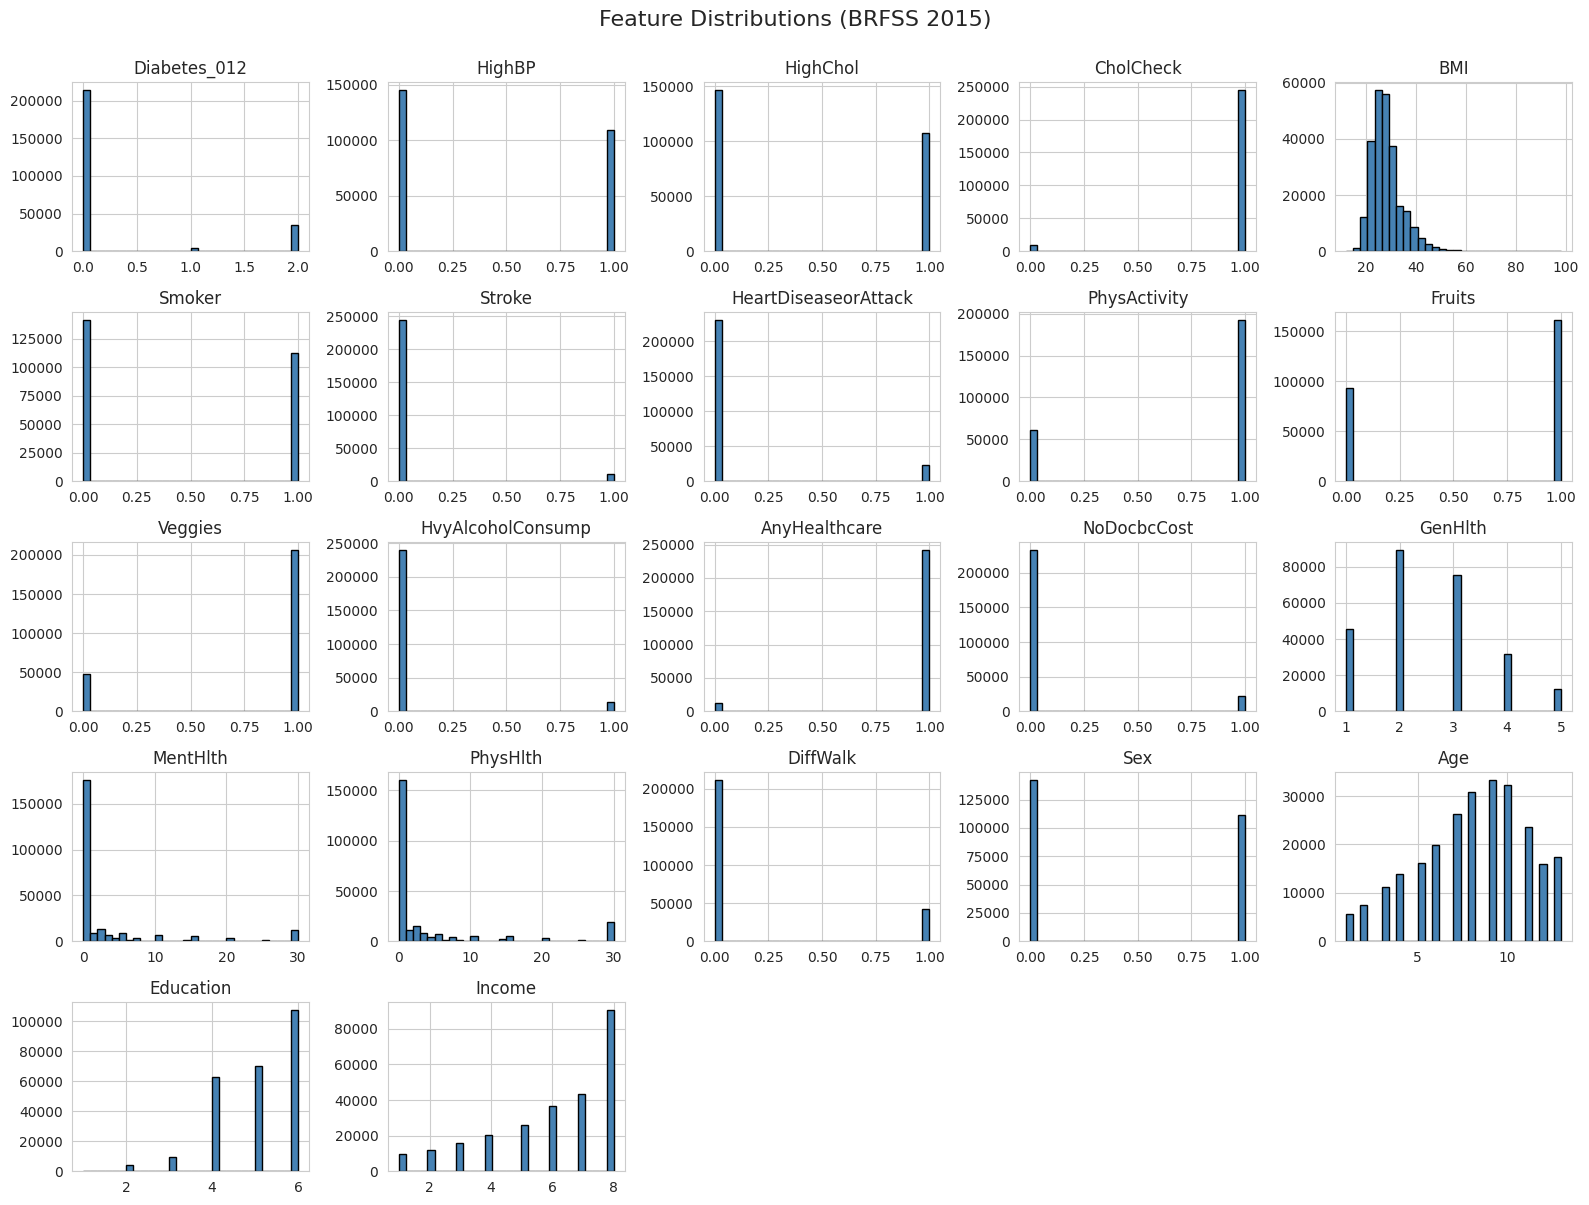

In [7]:
# Histograms of all features
df.hist(figsize=(16, 12), bins=30, edgecolor='black', color='steelblue')
plt.suptitle('Feature Distributions (BRFSS 2015)', fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig('fig_histograms.png', dpi=800, bbox_inches='tight')
plt.show()


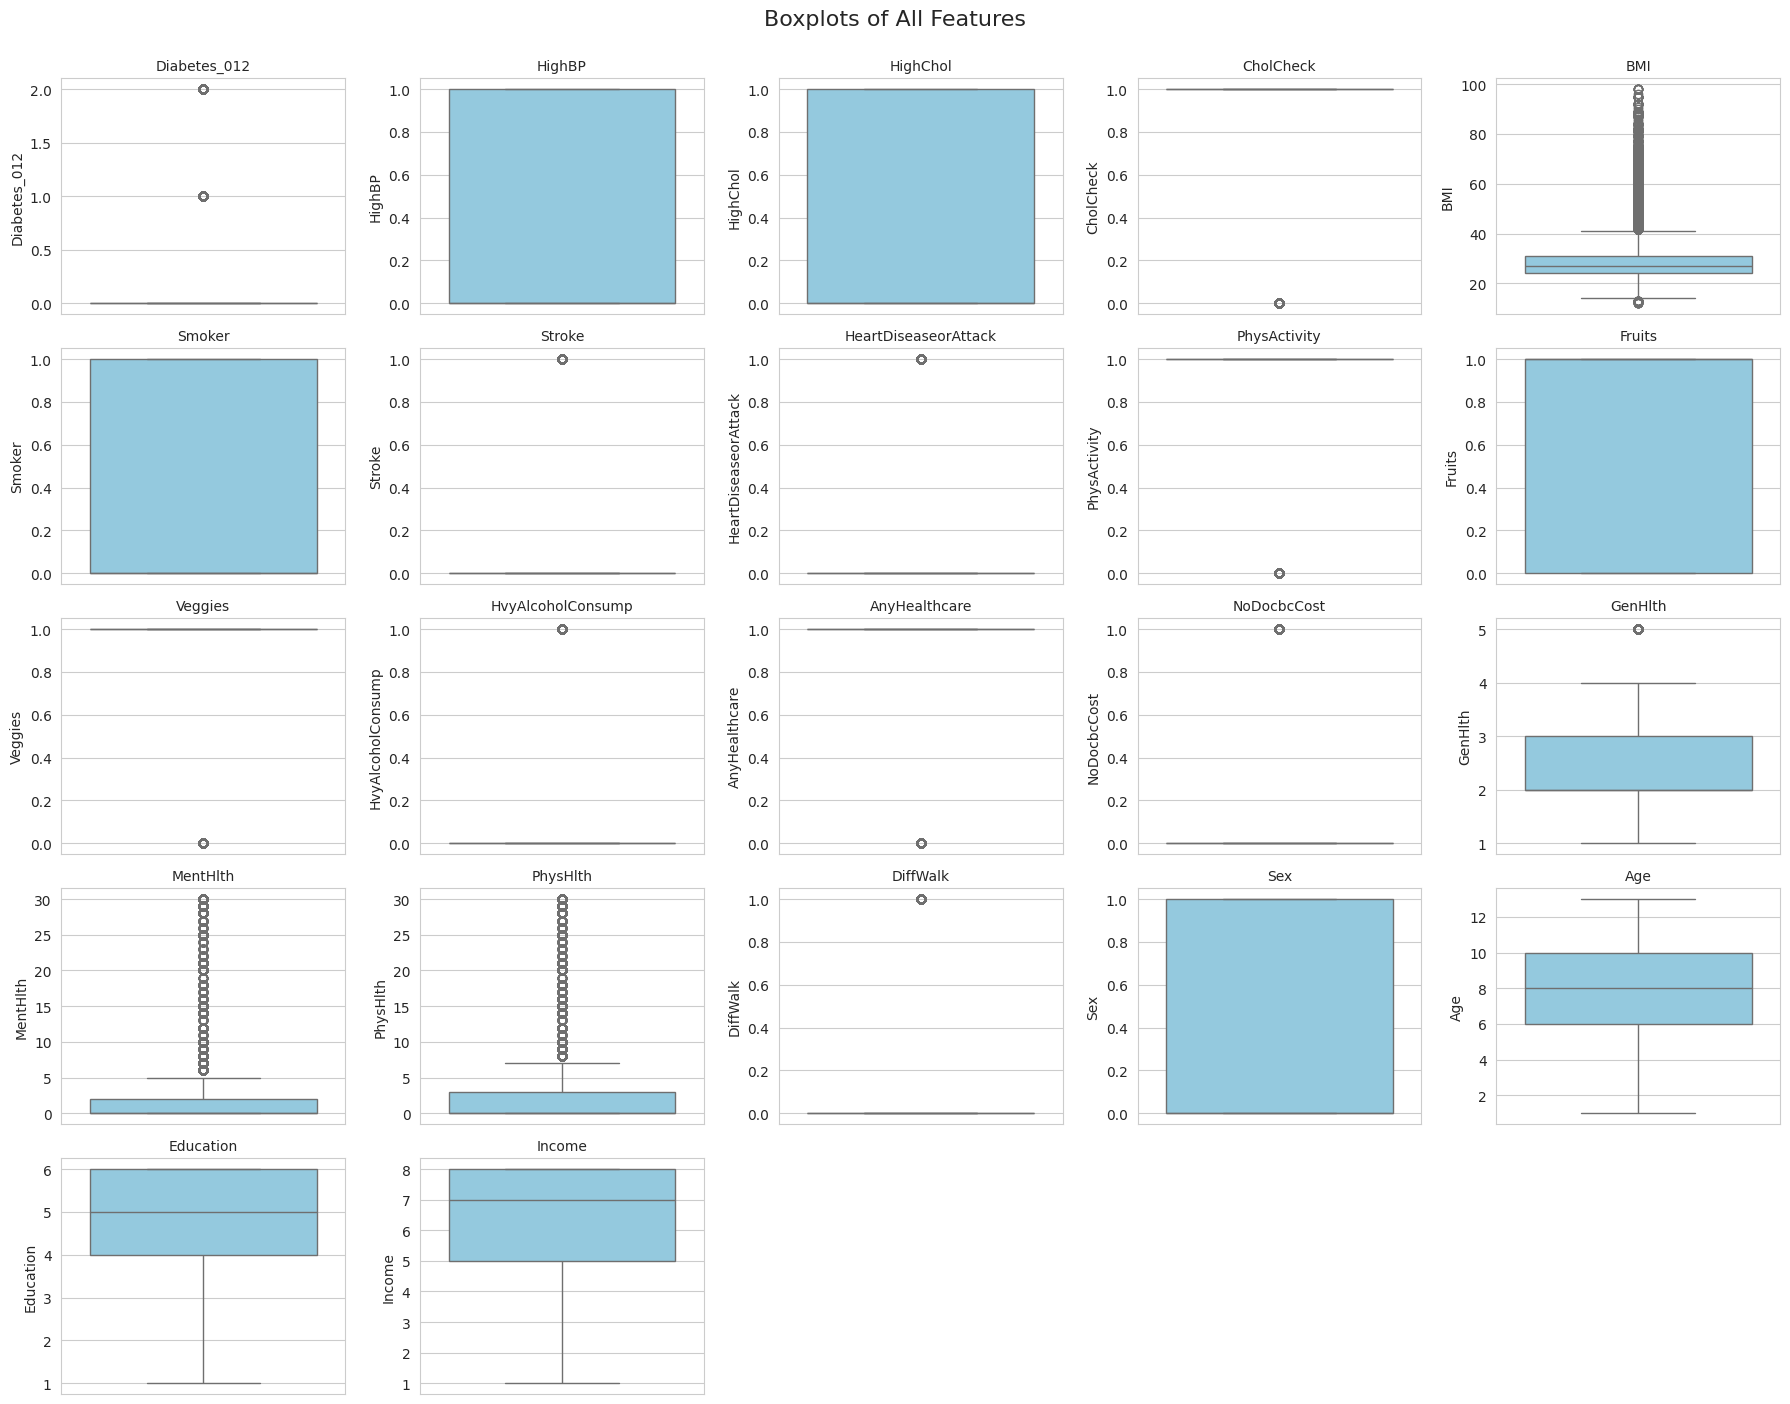

In [8]:
# Boxplots — useful to spot skew and outliers in BMI, MentHlth, PhysHlth, Age
fig, axes = plt.subplots(5, 5, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Boxplots of All Features', fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig('fig_boxplots.png', dpi=800, bbox_inches='tight')
plt.show()


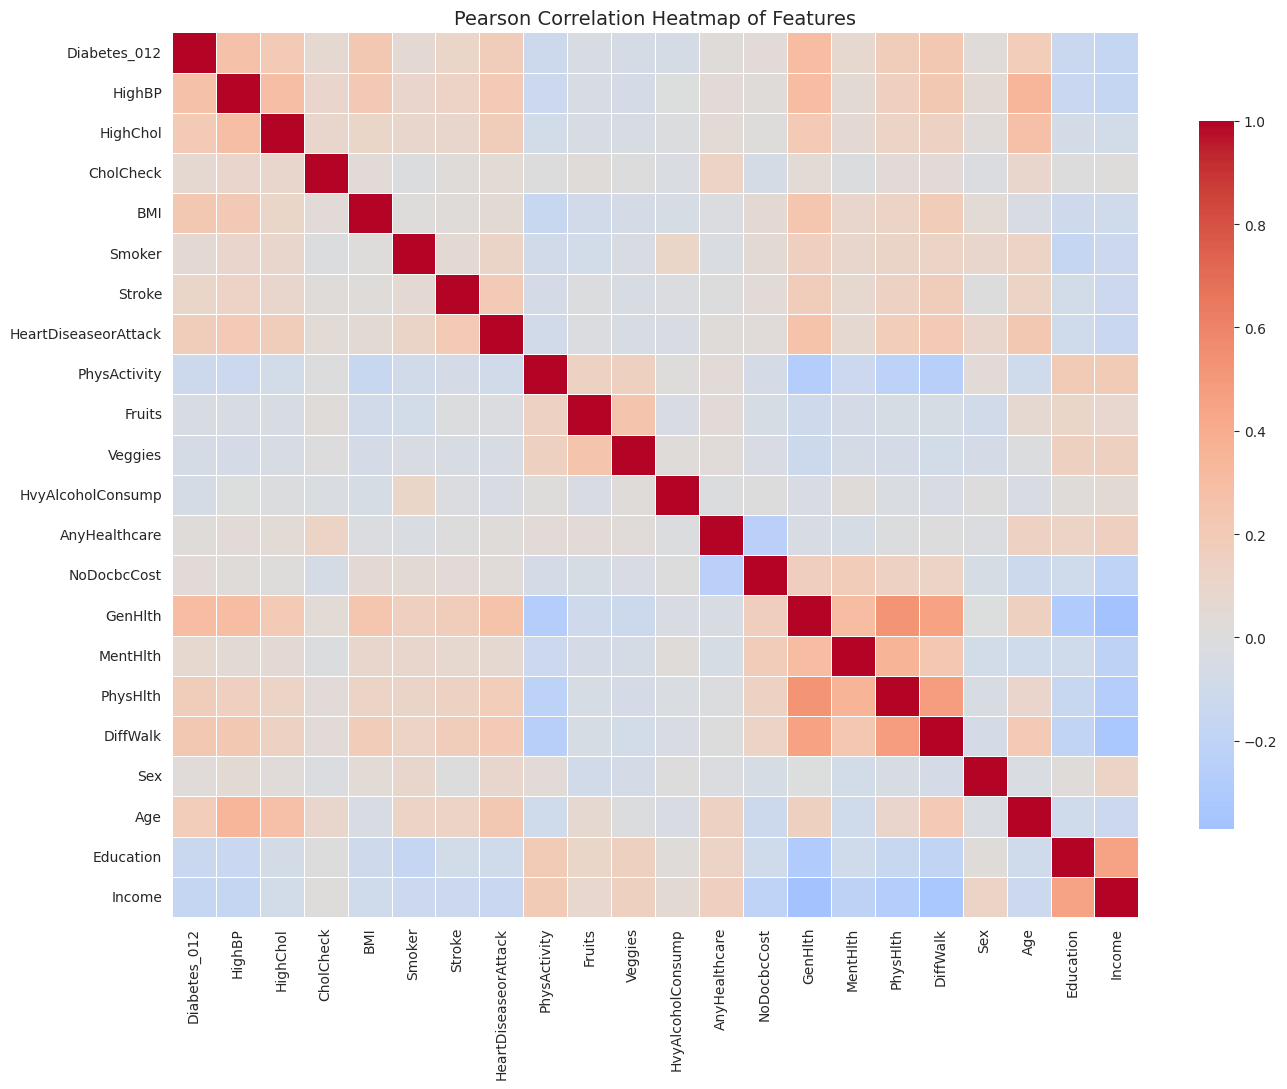

Top 10 features by |correlation| with Diabetes_012:
GenHlth                 0.303
HighBP                  0.272
BMI                     0.224
DiffWalk                0.224
HighChol                0.209
Age                     0.185
HeartDiseaseorAttack    0.180
PhysHlth                0.176
Income                  0.171
Education               0.131


In [9]:
# Correlation heatmap
plt.figure(figsize=(14, 11))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5, center=0,
            cbar_kws={'shrink': 0.8})
plt.title('Pearson Correlation Heatmap of Features', fontsize=14)
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=800, bbox_inches='tight')
plt.show()

# Print features most correlated with the target
target_corr = corr['Diabetes_012'].drop('Diabetes_012').abs().sort_values(ascending=False)
print('Top 10 features by |correlation| with Diabetes_012:')
print(target_corr.head(10).round(3).to_string())


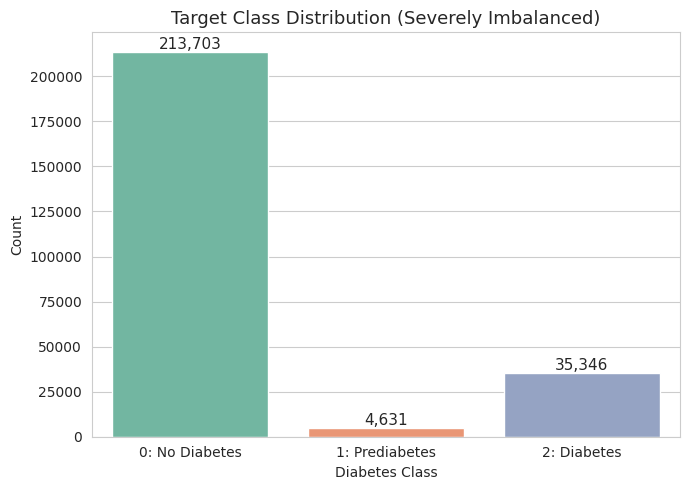

In [10]:
# Target class bar chart
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Diabetes_012', data=df, palette='Set2')
ax.set_title('Target Class Distribution (Severely Imbalanced)', fontsize=13)
ax.set_xlabel('Diabetes Class')
ax.set_ylabel('Count')
ax.set_xticklabels(['0: No Diabetes', '1: Prediabetes', '2: Diabetes'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('fig_class_distribution.png', dpi=800, bbox_inches='tight')
plt.show()


## 3. Processing Pipeline Overview

A programmatically generated pipeline diagram for the report.

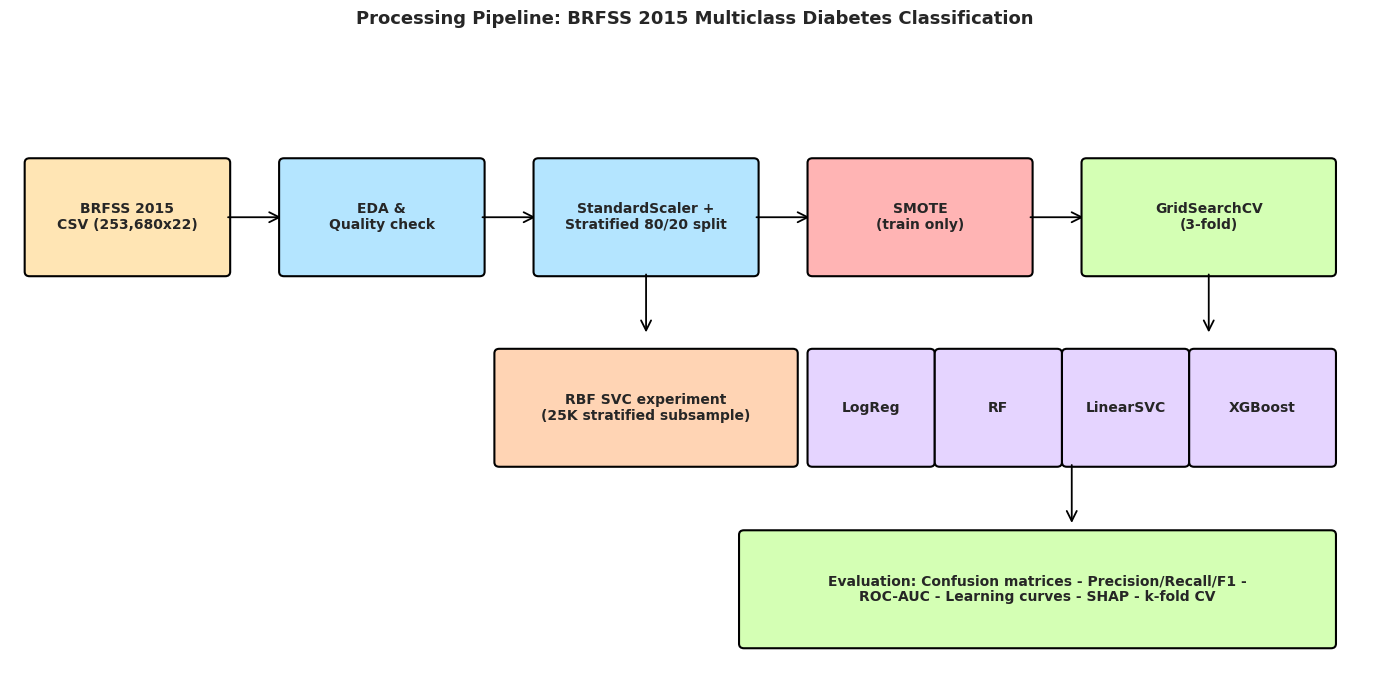

In [11]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14); ax.set_ylim(0, 7); ax.axis('off')

def box(x, y, w, h, text, color):
    b = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05',
                       linewidth=1.5, edgecolor='black', facecolor=color)
    ax.add_patch(b)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=10, fontweight='bold', wrap=True)

def arrow(x1, y1, x2, y2):
    a = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->',
                        mutation_scale=18, color='black', linewidth=1.3)
    ax.add_patch(a)

box(0.2, 4.5, 2.0, 1.2, 'BRFSS 2015\nCSV (253,680x22)', '#FFE5B4')
arrow(2.2, 5.1, 2.8, 5.1)
box(2.8, 4.5, 2.0, 1.2, 'EDA &\nQuality check', '#B4E5FF')
arrow(4.8, 5.1, 5.4, 5.1)
box(5.4, 4.5, 2.2, 1.2, 'StandardScaler +\nStratified 80/20 split', '#B4E5FF')
arrow(7.6, 5.1, 8.2, 5.1)
box(8.2, 4.5, 2.2, 1.2, 'SMOTE\n(train only)', '#FFB4B4')
arrow(10.4, 5.1, 11.0, 5.1)
box(11.0, 4.5, 2.5, 1.2, 'GridSearchCV\n(3-fold)', '#D4FFB4')

arrow(12.25, 4.5, 12.25, 3.8)
box(8.2, 2.4, 1.2, 1.2, 'LogReg', '#E5D4FF')
box(9.5, 2.4, 1.2, 1.2, 'RF', '#E5D4FF')
box(10.8, 2.4, 1.2, 1.2, 'LinearSVC', '#E5D4FF')
box(12.1, 2.4, 1.4, 1.2, 'XGBoost', '#E5D4FF')

arrow(10.85, 2.4, 10.85, 1.7)
box(7.5, 0.4, 6.0, 1.2,
    'Evaluation: Confusion matrices - Precision/Recall/F1 -\nROC-AUC - Learning curves - SHAP - k-fold CV',
    '#D4FFB4')

arrow(6.5, 4.5, 6.5, 3.8)
box(5.0, 2.4, 3.0, 1.2, 'RBF SVC experiment\n(25K stratified subsample)', '#FFD4B4')

plt.title('Processing Pipeline: BRFSS 2015 Multiclass Diabetes Classification',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_pipeline.png', dpi=800, bbox_inches='tight')
plt.show()


## 4. Data Preprocessing

- Stratified 80/20 split preserves the class proportions.
- `StandardScaler` is fit on the training data only (no leakage to test).

In [12]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012'].astype(int)

constant_cols = [c for c in X.columns if X[c].nunique() == 1]
if constant_cols:
    print(f'Dropping constant columns: {constant_cols}')
    X = X.drop(columns=constant_cols)

FEATURE_NAMES = list(X.columns)
print(f'Number of features: {len(FEATURE_NAMES)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}')
print(f'Train class distribution:')
print(pd.Series(y_train).value_counts(normalize=True).sort_index().round(4))


Number of features: 21
Train: (202944, 21), Test: (50736, 21)
Train class distribution:
Diabetes_012
0    0.8424
1    0.0183
2    0.1393
Name: proportion, dtype: float64


## 5. Baseline Models — No Resampling

All four models trained on the imbalanced data with `class_weight='balanced'` where supported.

*Note on SVM choice.* RBF-kernel SVC has O(n²)–O(n³) training cost. On 200K+ rows this is intractable on a normal laptop. We use `LinearSVC` here and run a dedicated RBF experiment on a 25K subsample in Section 8.

In [13]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, results_list=None):
    """Fit, predict, print classification report, and store metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average='macro')
    f1_weighted = f1_score(y_te, y_pred, average='weighted')
    prec_w = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec_w = recall_score(y_te, y_pred, average='weighted')

    print(f'\n=== {name} ===')
    print(classification_report(y_te, y_pred, digits=4, zero_division=0))
    print(f'Accuracy: {acc:.4f} | Macro-F1: {f1_macro:.4f} | Weighted-F1: {f1_weighted:.4f}')

    if results_list is not None:
        results_list.append({
            'Model': name,
            'Accuracy': acc,
            'Precision (w)': prec_w,
            'Recall (w)': rec_w,
            'F1 (weighted)': f1_weighted,
            'F1 (macro)': f1_macro,
        })
    return model, y_pred


In [14]:
baseline_results = []

models_baseline = {
    'LogReg (baseline)': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'RandomForest (baseline)': RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    'LinearSVC (baseline)': LinearSVC(
        class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE
    ),
    'XGBoost (baseline)': XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1
    ),
}

for name, mdl in models_baseline.items():
    evaluate_model(name, mdl, X_train_scaled, y_train,
                   X_test_scaled, y_test, baseline_results)



=== LogReg (baseline) ===
              precision    recall  f1-score   support

           0     0.9510    0.6630    0.7813     42741
           1     0.0326    0.3261    0.0593       926
           2     0.3533    0.5834    0.4401      7069

    accuracy                         0.6458     50736
   macro avg     0.4456    0.5242    0.4269     50736
weighted avg     0.8510    0.6458    0.7206     50736

Accuracy: 0.6458 | Macro-F1: 0.4269 | Weighted-F1: 0.7206

=== RandomForest (baseline) ===
              precision    recall  f1-score   support

           0     0.8590    0.9690    0.9107     42741
           1     0.0000    0.0000    0.0000       926
           2     0.4687    0.1579    0.2362      7069

    accuracy                         0.8383     50736
   macro avg     0.4426    0.3756    0.3823     50736
weighted avg     0.7889    0.8383    0.8001     50736

Accuracy: 0.8383 | Macro-F1: 0.3823 | Weighted-F1: 0.8001

=== LinearSVC (baseline) ===
              precision    recal

## 6. Handling Class Imbalance with SMOTE

The prediabetes class is only ~1.8% of the data; the baseline models above achieve high accuracy by essentially ignoring it. SMOTE generates synthetic minority samples by interpolating between existing minority points.

**Critical:** SMOTE is applied to the training set only. Resampling the test set would invalidate evaluation. When SMOTE is used we drop `class_weight='balanced'` because the two corrections stack.

In [15]:
print('Applying SMOTE to training data (~30s-1min)...')
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print('After SMOTE - class distribution:')
print(pd.Series(y_train_sm).value_counts().sort_index())
print(f'Total training samples: {len(y_train_sm):,}')


Applying SMOTE to training data (~30s-1min)...
After SMOTE - class distribution:
Diabetes_012
0    170962
1    170962
2    170962
Name: count, dtype: int64
Total training samples: 512,886


In [16]:
smote_results = []

models_smote = {
    'LogReg (SMOTE)': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE
    ),
    'RandomForest (SMOTE)': RandomForestClassifier(
        n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE
    ),
    'LinearSVC (SMOTE)': LinearSVC(
        max_iter=3000, random_state=RANDOM_STATE
    ),
    'XGBoost (SMOTE)': XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1
    ),
}

for name, mdl in models_smote.items():
    evaluate_model(name, mdl, X_train_sm, y_train_sm,
                   X_test_scaled, y_test, smote_results)



=== LogReg (SMOTE) ===
              precision    recall  f1-score   support

           0     0.9505    0.6602    0.7792     42741
           1     0.0313    0.3261    0.0572       926
           2     0.3544    0.5722    0.4377      7069

    accuracy                         0.6418     50736
   macro avg     0.4454    0.5195    0.4247     50736
weighted avg     0.8507    0.6418    0.7184     50736

Accuracy: 0.6418 | Macro-F1: 0.4247 | Weighted-F1: 0.7184

=== RandomForest (SMOTE) ===
              precision    recall  f1-score   support

           0     0.8809    0.9286    0.9041     42741
           1     0.0085    0.0011    0.0019       926
           2     0.4299    0.3381    0.3785      7069

    accuracy                         0.8294     50736
   macro avg     0.4397    0.4226    0.4282     50736
weighted avg     0.8021    0.8294    0.8144     50736

Accuracy: 0.8294 | Macro-F1: 0.4282 | Weighted-F1: 0.8144

=== LinearSVC (SMOTE) ===
              precision    recall  f1-sco

## 7. Hyperparameter Tuning (GridSearchCV)

3-fold stratified CV using macro-F1 as the scoring metric (weights all classes equally, directly targeting minority-class performance).

Grid sizes are kept modest to control run time (~15-25 minutes total on a typical laptop). Set `RUN_GRIDSEARCH = False` to skip while iterating.

In [17]:
RUN_GRIDSEARCH = True  # set False to skip tuning

best_models = {}

if RUN_GRIDSEARCH:
    print('--- Tuning Logistic Regression ---')
    grid_lr = GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']},
        cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
    )
    grid_lr.fit(X_train_sm, y_train_sm)
    best_models['LogReg'] = grid_lr.best_estimator_
    print('Best LR params:', grid_lr.best_params_)
    print('CV macro-F1:', round(grid_lr.best_score_, 4))


--- Tuning Logistic Regression ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best LR params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
CV macro-F1: 0.5176


In [18]:
if RUN_GRIDSEARCH:
    print('\n--- Tuning Random Forest ---')
    grid_rf = GridSearchCV(
        RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
        param_grid={
            'n_estimators': [100, 200],
            'max_depth': [None, 15, 25],
            'min_samples_split': [2, 5],
        },
        cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
    )
    grid_rf.fit(X_train_sm, y_train_sm)
    best_models['RandomForest'] = grid_rf.best_estimator_
    print('Best RF params:', grid_rf.best_params_)
    print('CV macro-F1:', round(grid_rf.best_score_, 4))



--- Tuning Random Forest ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
CV macro-F1: 0.9205


In [19]:
if RUN_GRIDSEARCH:
    print('\n--- Tuning Linear SVC ---')
    grid_svc = GridSearchCV(
        LinearSVC(max_iter=3000, random_state=RANDOM_STATE),
        param_grid={'C': [0.01, 0.1, 1]},
        cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
    )
    grid_svc.fit(X_train_sm, y_train_sm)
    best_models['LinearSVC'] = grid_svc.best_estimator_
    print('Best LinearSVC params:', grid_svc.best_params_)
    print('CV macro-F1:', round(grid_svc.best_score_, 4))



--- Tuning Linear SVC ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best LinearSVC params: {'C': 0.1}
CV macro-F1: 0.4994


In [20]:
if RUN_GRIDSEARCH:
    print('\n--- Tuning XGBoost ---')
    grid_xgb = GridSearchCV(
        XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1),
        param_grid={
            'n_estimators': [200, 400],
            'max_depth': [4, 6, 8],
            'learning_rate': [0.05, 0.1],
            'subsample': [0.8, 1.0],
        },
        cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
    )
    grid_xgb.fit(X_train_sm, y_train_sm)
    best_models['XGBoost'] = grid_xgb.best_estimator_
    print('Best XGB params:', grid_xgb.best_params_)
    print('CV macro-F1:', round(grid_xgb.best_score_, 4))



--- Tuning XGBoost ---
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best XGB params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400, 'subsample': 0.8}
CV macro-F1: 0.8666


## 8. RBF-Kernel SVC on a Stratified Subsample

To justify the `LinearSVC` choice rigorously, we train an RBF-kernel SVC on a 25,000-row stratified subsample of the training data and evaluate on the full test set. If RBF doesn't beat LinearSVC even on the subsample, the linear choice is empirically justified.

In [21]:
RUN_RBF_EXPERIMENT = True

if RUN_RBF_EXPERIMENT:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=25000, random_state=RANDOM_STATE)
    idx_sub, _ = next(sss.split(X_train_scaled, y_train))
    X_train_sub = X_train_scaled[idx_sub]
    y_train_sub = y_train.iloc[idx_sub]
    print(f'RBF subsample shape: {X_train_sub.shape}')
    print(f'Subsample class distribution: '
          f'{pd.Series(y_train_sub).value_counts().sort_index().to_dict()}')

    print('Training RBF SVC on subsample (this takes ~5-10 minutes)...')
    rbf_svc = SVC(kernel='rbf', C=1.0, gamma='scale',
                  class_weight='balanced', random_state=RANDOM_STATE)
    rbf_svc.fit(X_train_sub, y_train_sub)
    y_pred_rbf = rbf_svc.predict(X_test_scaled)
    print('\nRBF SVC (25K subsample) - test performance:')
    print(classification_report(y_test, y_pred_rbf, digits=4, zero_division=0))


RBF subsample shape: (25000, 21)
Subsample class distribution: {0: 21060, 1: 457, 2: 3483}
Training RBF SVC on subsample (this takes ~5-10 minutes)...

RBF SVC (25K subsample) - test performance:
              precision    recall  f1-score   support

           0     0.9425    0.6713    0.7841     42741
           1     0.0276    0.2181    0.0490       926
           2     0.3236    0.5936    0.4188      7069

    accuracy                         0.6522     50736
   macro avg     0.4312    0.4943    0.4173     50736
weighted avg     0.8396    0.6522    0.7198     50736



## 9. Final Evaluation of Tuned Models

Confusion matrices and per-class metrics on the held-out test set.

In [22]:
final_results = []
predictions = {}

for name, mdl in best_models.items():
    print(f'\n=== Tuned {name} (SMOTE) ===')
    y_pred = mdl.predict(X_test_scaled)
    predictions[name] = y_pred

    print(classification_report(
        y_test, y_pred, digits=4, zero_division=0,
        target_names=['No Diabetes', 'Prediabetes', 'Diabetes']
    ))

    final_results.append({
        'Model': f'Tuned {name}',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (w)': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall (w)': recall_score(y_test, y_pred, average='weighted'),
        'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
    })



=== Tuned LogReg (SMOTE) ===
              precision    recall  f1-score   support

 No Diabetes     0.9505    0.6602    0.7792     42741
 Prediabetes     0.0313    0.3261    0.0572       926
    Diabetes     0.3544    0.5722    0.4377      7069

    accuracy                         0.6418     50736
   macro avg     0.4454    0.5195    0.4247     50736
weighted avg     0.8507    0.6418    0.7184     50736


=== Tuned RandomForest (SMOTE) ===
              precision    recall  f1-score   support

 No Diabetes     0.8816    0.9289    0.9047     42741
 Prediabetes     0.0087    0.0011    0.0019       926
    Diabetes     0.4339    0.3429    0.3831      7069

    accuracy                         0.8303     50736
   macro avg     0.4414    0.4243    0.4299     50736
weighted avg     0.8033    0.8303    0.8155     50736


=== Tuned LinearSVC (SMOTE) ===
              precision    recall  f1-score   support

 No Diabetes     0.9433    0.6977    0.8021     42741
 Prediabetes     0.0341    0.2

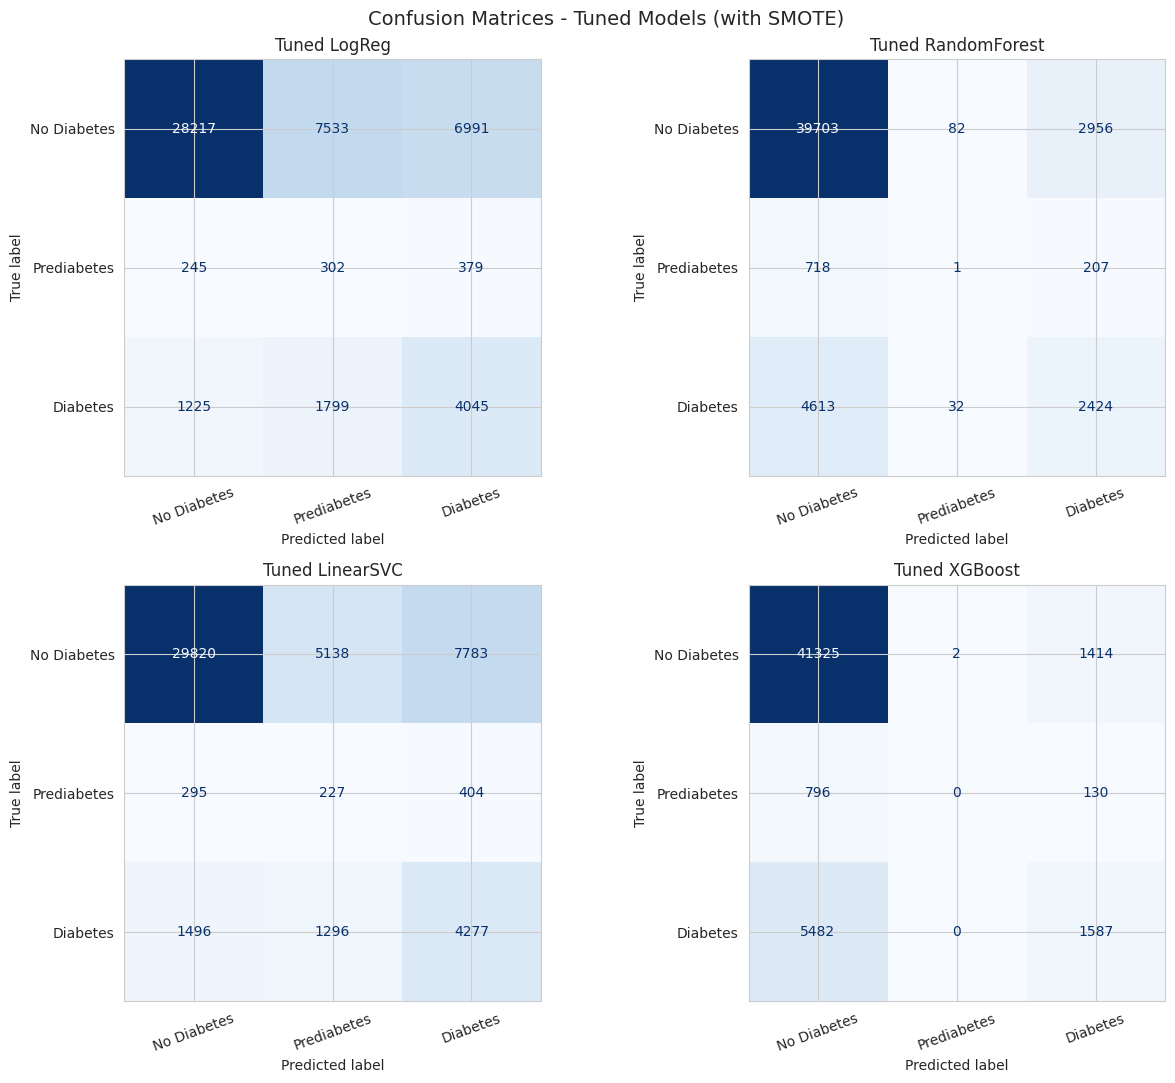

In [23]:
# Confusion matrices for all 4 tuned models
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()
labels = ['No Diabetes', 'Prediabetes', 'Diabetes']

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
    axes[i].set_title(f'Tuned {name}', fontsize=12)
    axes[i].set_xticklabels(labels, rotation=20)

plt.suptitle('Confusion Matrices - Tuned Models (with SMOTE)', fontsize=14)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=800, bbox_inches='tight')
plt.show()


## 10. Best Models — Dual Winners

The paper's central narrative is that *the best model depends on the metric*. We carry two winners forward: one by macro-F1 (best for minority-class detection / clinical screening) and one by overall accuracy (best for headline predictive performance).

In [24]:
# Two winners: one by macro-F1 (minority-aware), one by overall accuracy
best_by_f1  = max(final_results, key=lambda r: r['F1 (macro)'])['Model'].replace('Tuned ', '')
best_by_acc = max(final_results, key=lambda r: r['Accuracy'])['Model'].replace('Tuned ', '')

best_model_f1  = best_models[best_by_f1]
best_model_acc = best_models[best_by_acc]

print(f'Best model by macro-F1:         {best_by_f1}   '
      f"(macro-F1 = {max(r['F1 (macro)'] for r in final_results):.4f})")
print(f'Best model by overall accuracy: {best_by_acc}  '
      f"(accuracy = {max(r['Accuracy'] for r in final_results):.4f})")


Best model by macro-F1:         LinearSVC   (macro-F1 = 0.4333)
Best model by overall accuracy: XGBoost  (accuracy = 0.8458)


## 11. Learning Curves — Both Winners

A learning curve shows training vs. cross-validation score as the training set grows. It diagnoses whether more data would help (gap closing slowly = high variance / overfitting) or whether the model has hit its capacity ceiling (gap small and flat = low variance, possibly high bias).

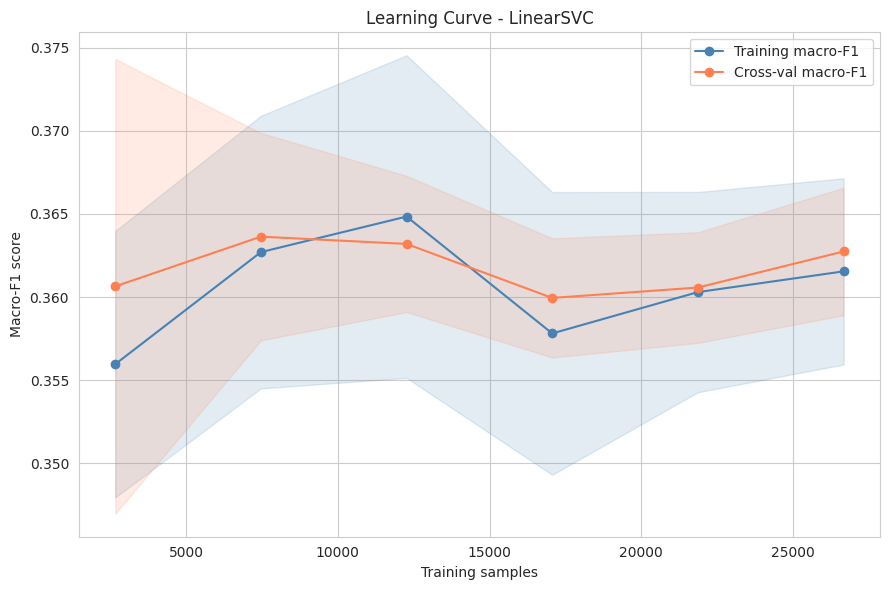

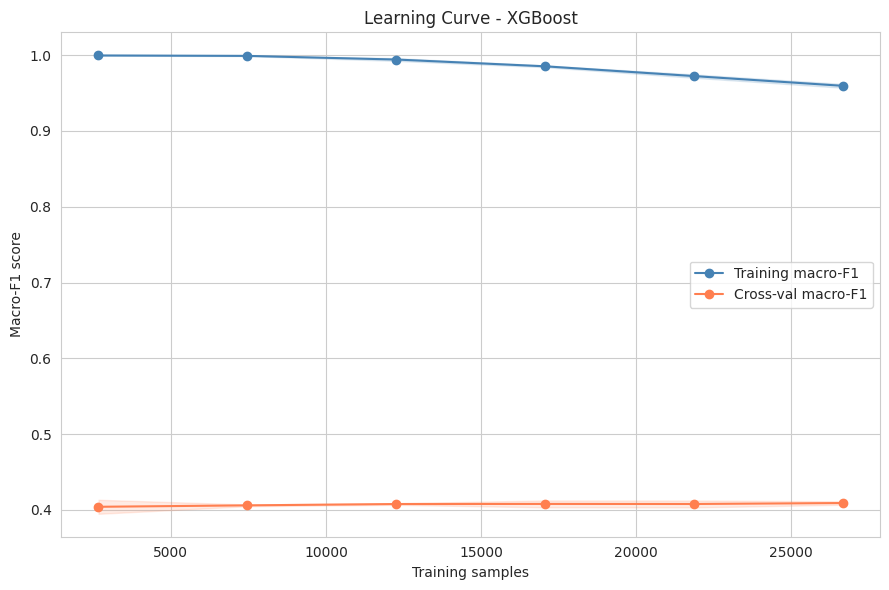

In [25]:
# Stratified subsample for learning curve speed (full 200K would be very slow)
sss_lc = StratifiedShuffleSplit(n_splits=1, train_size=40000, random_state=RANDOM_STATE)
idx_lc, _ = next(sss_lc.split(X_train_scaled, y_train))
X_lc = X_train_scaled[idx_lc]
y_lc = y_train.iloc[idx_lc]

def plot_learning_curve(model, name, savepath):
    train_sizes = np.linspace(0.1, 1.0, 6)
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X_lc, y_lc,
        train_sizes=train_sizes, cv=3, scoring='f1_macro',
        n_jobs=-1, random_state=RANDOM_STATE
    )
    tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
    vm, vs = val_scores.mean(axis=1), val_scores.std(axis=1)

    plt.figure(figsize=(9, 6))
    plt.plot(train_sizes_abs, tm, 'o-', color='steelblue', label='Training macro-F1')
    plt.fill_between(train_sizes_abs, tm - ts, tm + ts, alpha=0.15, color='steelblue')
    plt.plot(train_sizes_abs, vm, 'o-', color='coral', label='Cross-val macro-F1')
    plt.fill_between(train_sizes_abs, vm - vs, vm + vs, alpha=0.15, color='coral')
    plt.xlabel('Training samples'); plt.ylabel('Macro-F1 score')
    plt.title(f'Learning Curve - {name}')
    plt.legend(loc='best'); plt.grid(True)
    plt.tight_layout()
    plt.savefig(savepath, dpi=800, bbox_inches='tight')
    plt.show()

plot_learning_curve(best_model_f1,  best_by_f1,  'fig_learning_curve_f1.png')

if best_by_acc != best_by_f1:
    plot_learning_curve(best_model_acc, best_by_acc, 'fig_learning_curve_acc.png')


## 12. XGBoost Loss Curve (Train vs. Test)

XGBoost natively supports per-round loss tracking via `eval_set`. This is the loss-curve figure preferred by the rubric.

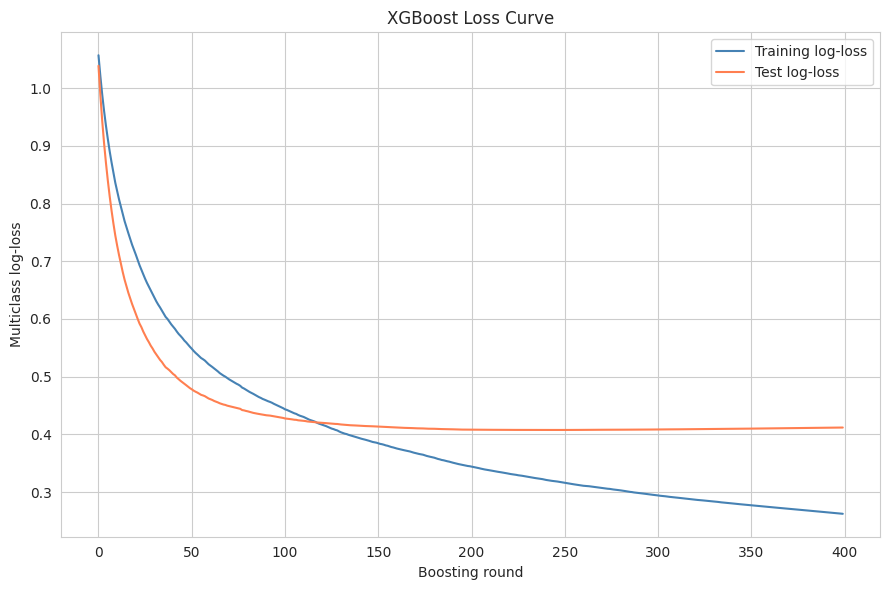

In [26]:
xgb_for_loss = XGBClassifier(**best_models['XGBoost'].get_params())
xgb_for_loss.set_params(eval_metric='mlogloss')

xgb_for_loss.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_train_sm, y_train_sm), (X_test_scaled, y_test)],
    verbose=False
)

results_xgb = xgb_for_loss.evals_result()
epochs = range(len(results_xgb['validation_0']['mlogloss']))

plt.figure(figsize=(9, 6))
plt.plot(epochs, results_xgb['validation_0']['mlogloss'], label='Training log-loss', color='steelblue')
plt.plot(epochs, results_xgb['validation_1']['mlogloss'], label='Test log-loss', color='coral')
plt.xlabel('Boosting round'); plt.ylabel('Multiclass log-loss')
plt.title('XGBoost Loss Curve')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig('fig_loss_curve.png', dpi=800, bbox_inches='tight')
plt.show()


## 13. ROC Curves (One-vs-Rest) — Both Winners

For each class we compute the ROC curve in the one-vs-rest formulation. `LinearSVC` doesn't expose probabilities, but ROC-AUC is invariant under monotonic transforms, so uncalibrated decision-function scores yield the same curve as calibrated probabilities would.

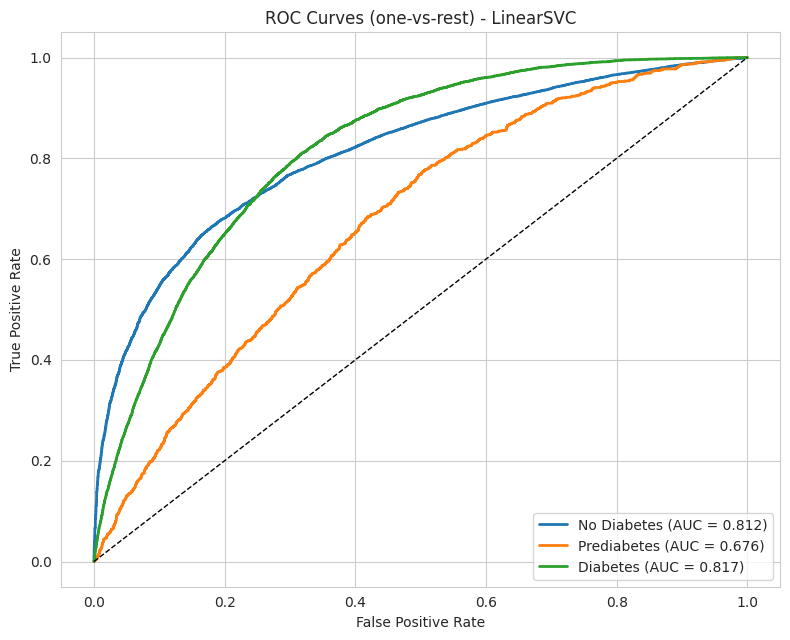

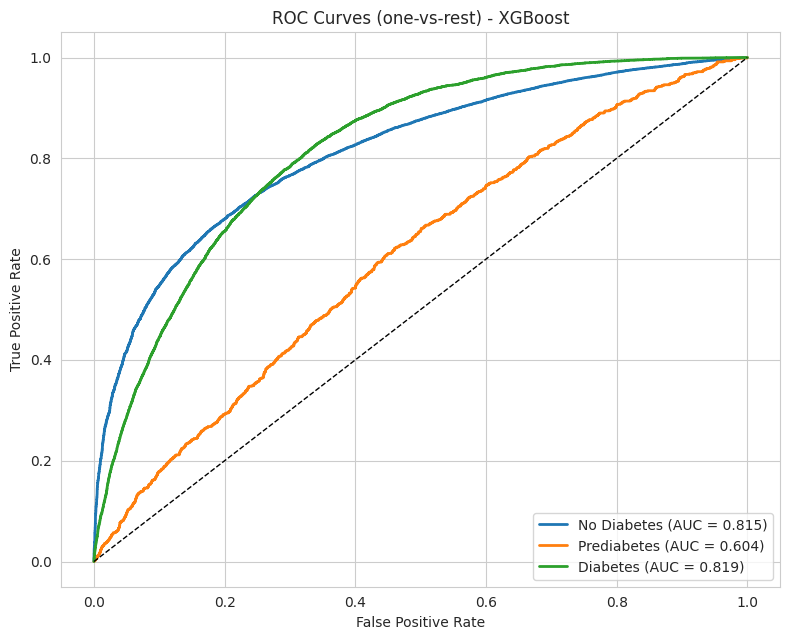

In [27]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

def plot_roc(model, name, savepath):
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test_scaled)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test_scaled)
    else:
        raise ValueError('Model has neither predict_proba nor decision_function')

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6.5))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    class_names = ['No Diabetes', 'Prediabetes', 'Diabetes']
    for i, c, n in zip(range(n_classes), colors, class_names):
        plt.plot(fpr[i], tpr[i], color=c, lw=2,
                 label=f'{n} (AUC = {roc_auc[i]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves (one-vs-rest) - {name}')
    plt.legend(loc='lower right'); plt.grid(True)
    plt.tight_layout()
    plt.savefig(savepath, dpi=800, bbox_inches='tight')
    plt.show()

plot_roc(best_model_f1,  best_by_f1,  'fig_roc_f1.png')

if best_by_acc != best_by_f1:
    plot_roc(best_model_acc, best_by_acc, 'fig_roc_acc.png')


## 14. Feature Importance — With Proper Feature Names

Three views: Random Forest impurity, XGBoost gain (with f0/f1/... mapped back to real names), and LinearSVC coefficients for the Diabetes class.

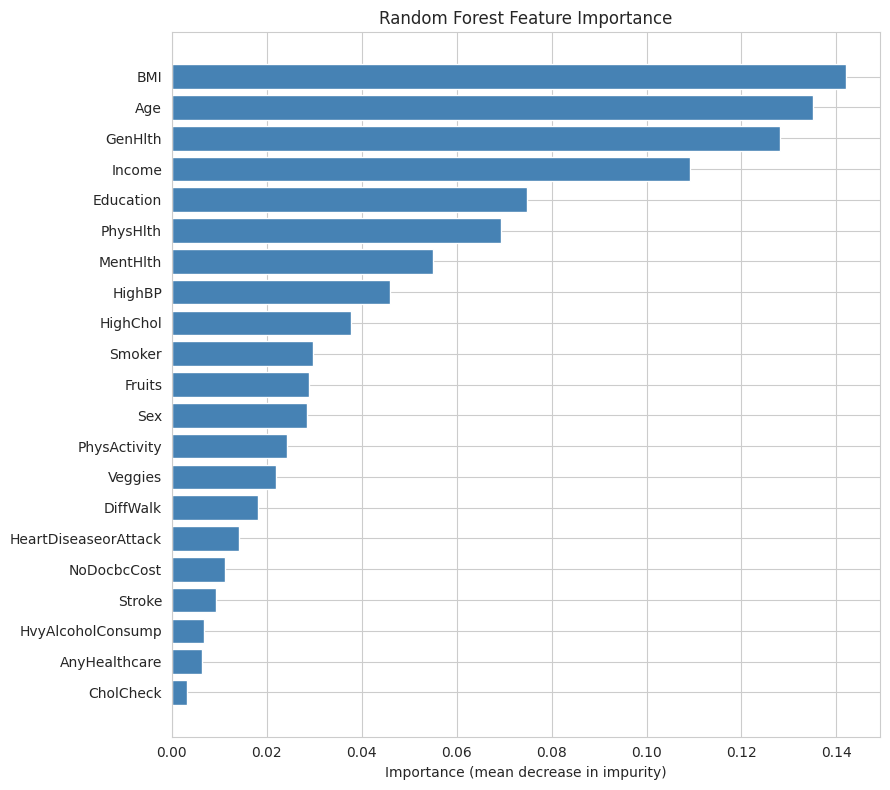

In [28]:
# Random Forest importance
if 'RandomForest' in best_models:
    rf = best_models['RandomForest']
    importances = rf.feature_importances_
    fi_rf = pd.DataFrame({'feature': FEATURE_NAMES, 'importance': importances})
    fi_rf = fi_rf.sort_values('importance', ascending=True)

    plt.figure(figsize=(9, 8))
    plt.barh(fi_rf['feature'], fi_rf['importance'], color='steelblue')
    plt.xlabel('Importance (mean decrease in impurity)')
    plt.title('Random Forest Feature Importance')
    plt.tight_layout()
    plt.savefig('fig_rf_importance.png', dpi=800, bbox_inches='tight')
    plt.show()


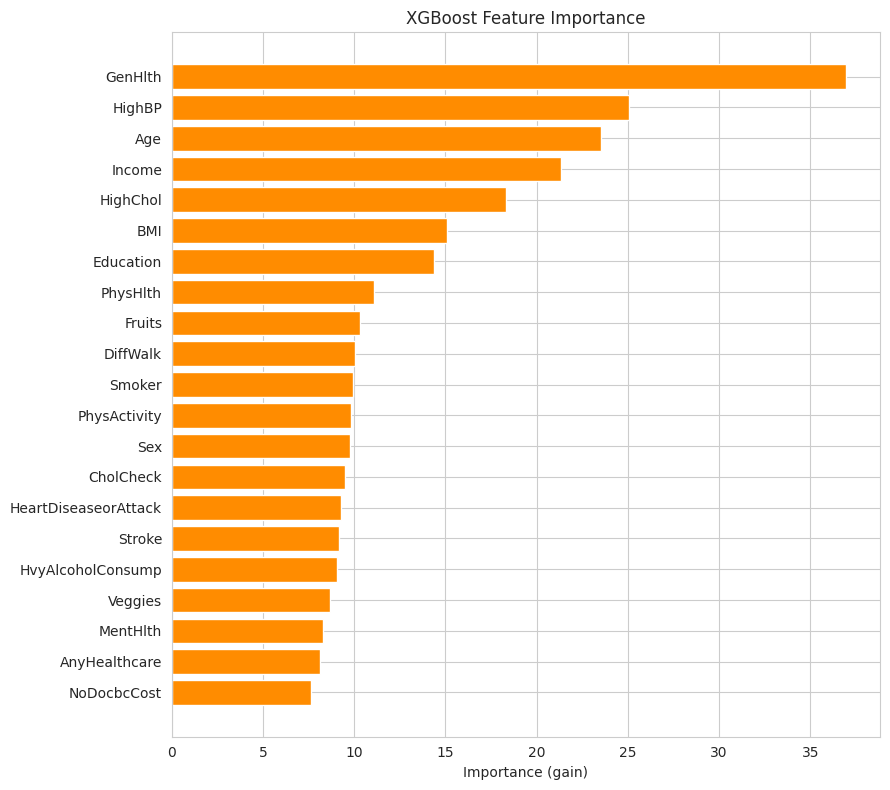

In [29]:
# XGBoost importance - with proper feature names
if 'XGBoost' in best_models:
    xgb_model = best_models['XGBoost']
    booster = xgb_model.get_booster()
    score_dict = booster.get_score(importance_type='gain')
    feature_map = {f'f{i}': name for i, name in enumerate(FEATURE_NAMES)}
    fi_xgb = pd.DataFrame([
        {'feature': feature_map.get(k, k), 'gain': v}
        for k, v in score_dict.items()
    ]).sort_values('gain', ascending=True)

    plt.figure(figsize=(9, 8))
    plt.barh(fi_xgb['feature'], fi_xgb['gain'], color='darkorange')
    plt.xlabel('Importance (gain)')
    plt.title('XGBoost Feature Importance')
    plt.tight_layout()
    plt.savefig('fig_xgb_importance.png', dpi=800, bbox_inches='tight')
    plt.show()


Top 10 LinearSVC features ranked by |coefficient| for Diabetes class:
                      No Diabetes  Prediabetes  Diabetes
GenHlth                    -0.227        0.033     0.200
BMI                        -0.180        0.043     0.122
HighBP                     -0.109        0.007     0.105
Age                        -0.217        0.119     0.104
HvyAlcoholConsump           0.035        0.012    -0.055
HighChol                   -0.120        0.073     0.047
CholCheck                  -0.067        0.031     0.046
Sex                        -0.031       -0.011     0.045
HeartDiseaseorAttack        0.002       -0.035     0.030
MentHlth                    0.001        0.027    -0.028


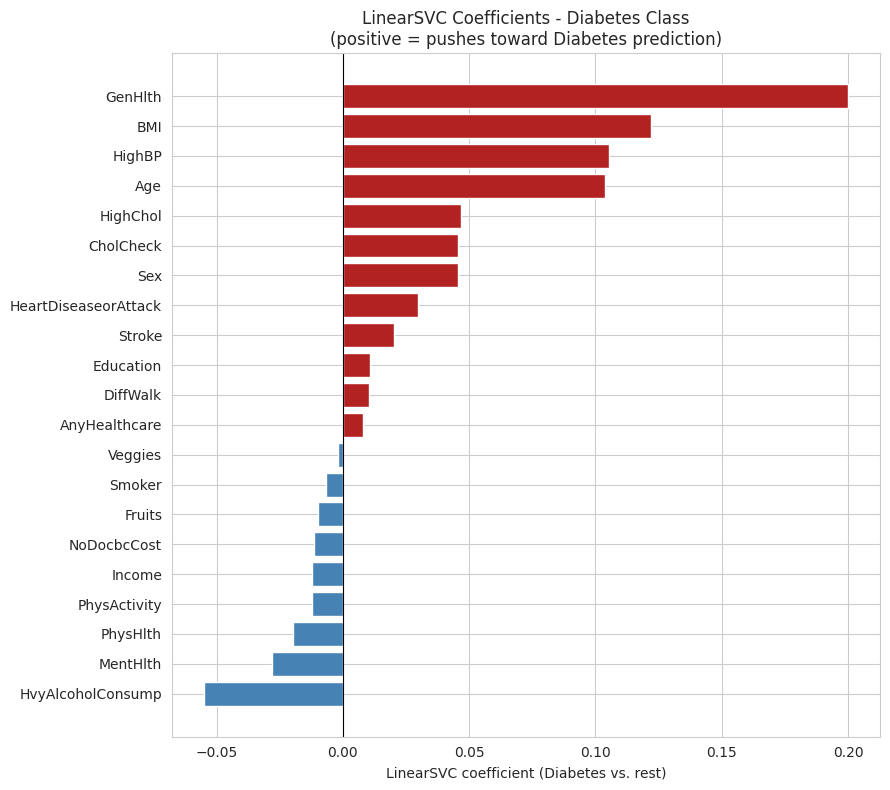

In [30]:
# LinearSVC coefficients - the linear analog of feature importance
if 'LinearSVC' in best_models:
    svc = best_models['LinearSVC']
    coef_df = pd.DataFrame(
        svc.coef_.T,
        index=FEATURE_NAMES,
        columns=['No Diabetes', 'Prediabetes', 'Diabetes']
    )
    coef_df['abs_diabetes'] = coef_df['Diabetes'].abs()
    top10 = coef_df.sort_values('abs_diabetes', ascending=False).head(10)
    top10_display = top10[['No Diabetes', 'Prediabetes', 'Diabetes']].round(3)
    print('Top 10 LinearSVC features ranked by |coefficient| for Diabetes class:')
    print(top10_display.to_string())

    plot_df = coef_df.sort_values('Diabetes', ascending=True)
    colors = ['steelblue' if v < 0 else 'firebrick' for v in plot_df['Diabetes']]
    plt.figure(figsize=(9, 8))
    plt.barh(plot_df.index, plot_df['Diabetes'], color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('LinearSVC coefficient (Diabetes vs. rest)')
    plt.title('LinearSVC Coefficients - Diabetes Class\n(positive = pushes toward Diabetes prediction)')
    plt.tight_layout()
    plt.savefig('fig_svc_coefficients.png', dpi=800, bbox_inches='tight')
    plt.show()


## 15. SHAP Analysis (XGBoost)

SHAP gives per-feature, per-prediction attribution that is both locally and globally consistent. We compute it on a 1,000-row test sample for speed.

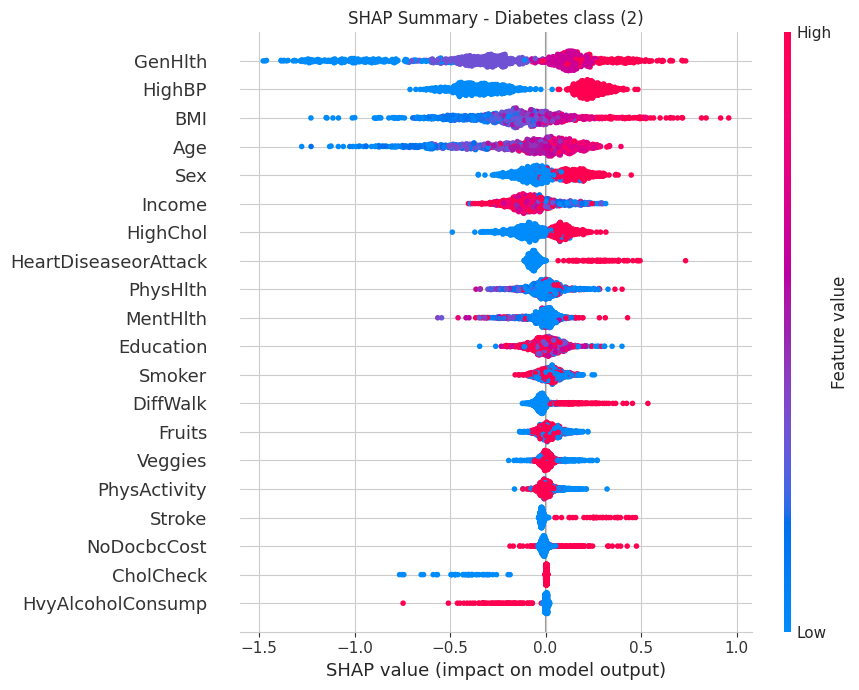

In [31]:
if SHAP_AVAILABLE and 'XGBoost' in best_models:
    sample_idx = np.random.choice(len(X_test_scaled), size=1000, replace=False)
    X_shap = pd.DataFrame(X_test_scaled[sample_idx], columns=FEATURE_NAMES)

    explainer = shap.TreeExplainer(best_models['XGBoost'])
    shap_values = explainer.shap_values(X_shap)

    # For multiclass, shap_values is a list or 3D array - handle both
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[2], X_shap, show=False, plot_size=(9, 7))
    else:
        shap.summary_plot(shap_values[:, :, 2], X_shap, show=False, plot_size=(9, 7))
    plt.title('SHAP Summary - Diabetes class (2)')
    plt.tight_layout()
    plt.savefig('fig_shap.png', dpi=800, bbox_inches='tight')
    plt.show()
else:
    print('SHAP skipped (library not installed or XGBoost not trained).')


## 16. Stratified 5-Fold Cross-Validation

A single train/test split is sensitive to which rows landed where. 5-fold stratified CV on a 50K subsample gives a more robust mean ± std estimate of model performance.

In [32]:
sss_cv = StratifiedShuffleSplit(n_splits=1, train_size=50000, random_state=RANDOM_STATE)
idx_cv, _ = next(sss_cv.split(X_train_scaled, y_train))
X_cv = X_train_scaled[idx_cv]
y_cv = y_train.iloc[idx_cv]

cv_summary = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, mdl in best_models.items():
    scores = cross_val_score(mdl, X_cv, y_cv, cv=skf, scoring='f1_macro', n_jobs=-1)
    cv_summary.append({
        'Model': name,
        'CV macro-F1 (mean)': scores.mean(),
        'CV macro-F1 (std)': scores.std(),
    })
    print(f'{name}: macro-F1 = {scores.mean():.4f} +/- {scores.std():.4f}')

cv_df = pd.DataFrame(cv_summary)
cv_df


LogReg: macro-F1 = 0.3974 +/- 0.0019
RandomForest: macro-F1 = 0.3962 +/- 0.0020
LinearSVC: macro-F1 = 0.3635 +/- 0.0031
XGBoost: macro-F1 = 0.4081 +/- 0.0027


,Model,CV macro-F1 (mean),CV macro-F1 (std)
0,LogReg,0.397438,0.001903
1,RandomForest,0.396186,0.002023
2,LinearSVC,0.363450,0.003052
3,XGBoost,0.408122,0.002749


## 17. Per-class Precision / Recall / F1 Comparison

Grouped-bar view that exposes the linear-vs-tree-based trade-off: linear models give nonzero recall on prediabetes at the cost of class-0 precision; tree-based models do the reverse.

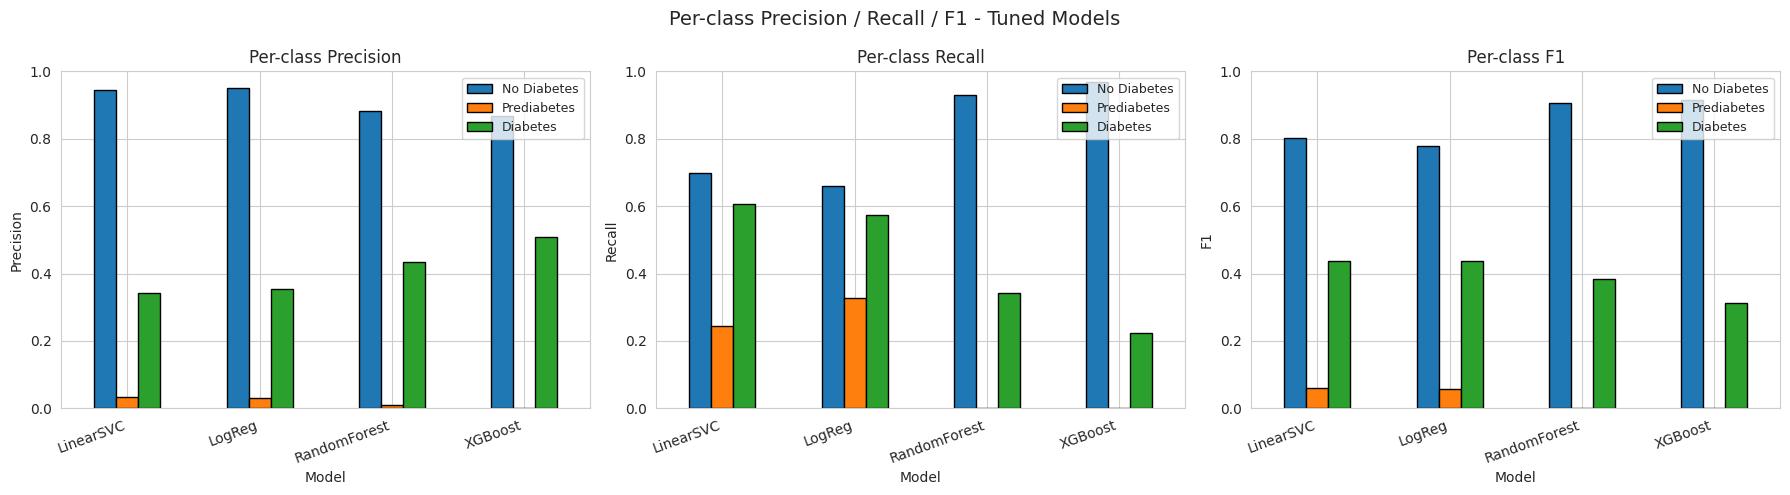

,Model,Class,Precision,Recall,F1
0,LogReg,No Diabetes,0.9505,0.6602,0.7792
1,LogReg,Prediabetes,0.0313,0.3261,0.0572
2,LogReg,Diabetes,0.3544,0.5722,0.4377
3,RandomForest,No Diabetes,0.8816,0.9289,0.9047
4,RandomForest,Prediabetes,0.0087,0.0011,0.0019
5,RandomForest,Diabetes,0.4339,0.3429,0.3831
6,LinearSVC,No Diabetes,0.9433,0.6977,0.8021
7,LinearSVC,Prediabetes,0.0341,0.2451,0.0598
8,LinearSVC,Diabetes,0.3431,0.6050,0.4379
9,XGBoost,No Diabetes,0.8681,0.9669,0.9148


In [33]:
prf_rows = []
for name, mdl in best_models.items():
    y_pred = mdl.predict(X_test_scaled)
    p, r, f, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[0, 1, 2], zero_division=0
    )
    for i, cls in enumerate(['No Diabetes', 'Prediabetes', 'Diabetes']):
        prf_rows.append({'Model': name, 'Class': cls,
                         'Precision': p[i], 'Recall': r[i], 'F1': f[i]})
prf_df = pd.DataFrame(prf_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['Precision', 'Recall', 'F1']):
    piv = prf_df.pivot(index='Model', columns='Class', values=metric)
    piv = piv[['No Diabetes', 'Prediabetes', 'Diabetes']]
    piv.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
    ax.set_title(f'Per-class {metric}', fontsize=12)
    ax.set_ylabel(metric); ax.set_ylim(0, 1)
    ax.set_xticklabels(piv.index, rotation=20, ha='right')
    ax.legend(loc='upper right', fontsize=9)
plt.suptitle('Per-class Precision / Recall / F1 - Tuned Models', fontsize=14)
plt.tight_layout()
plt.savefig('fig_prf_comparison.png', dpi=800, bbox_inches='tight')
plt.show()
prf_df.round(4)


## 18. Macro vs Weighted vs Accuracy — All 12 Configurations

A single chart that shows the inverse relationship between macro-F1 (minority-aware) and accuracy / weighted-F1 (majority-dominated) across every configuration in the study. This is the empirical signature of the class-imbalance problem.

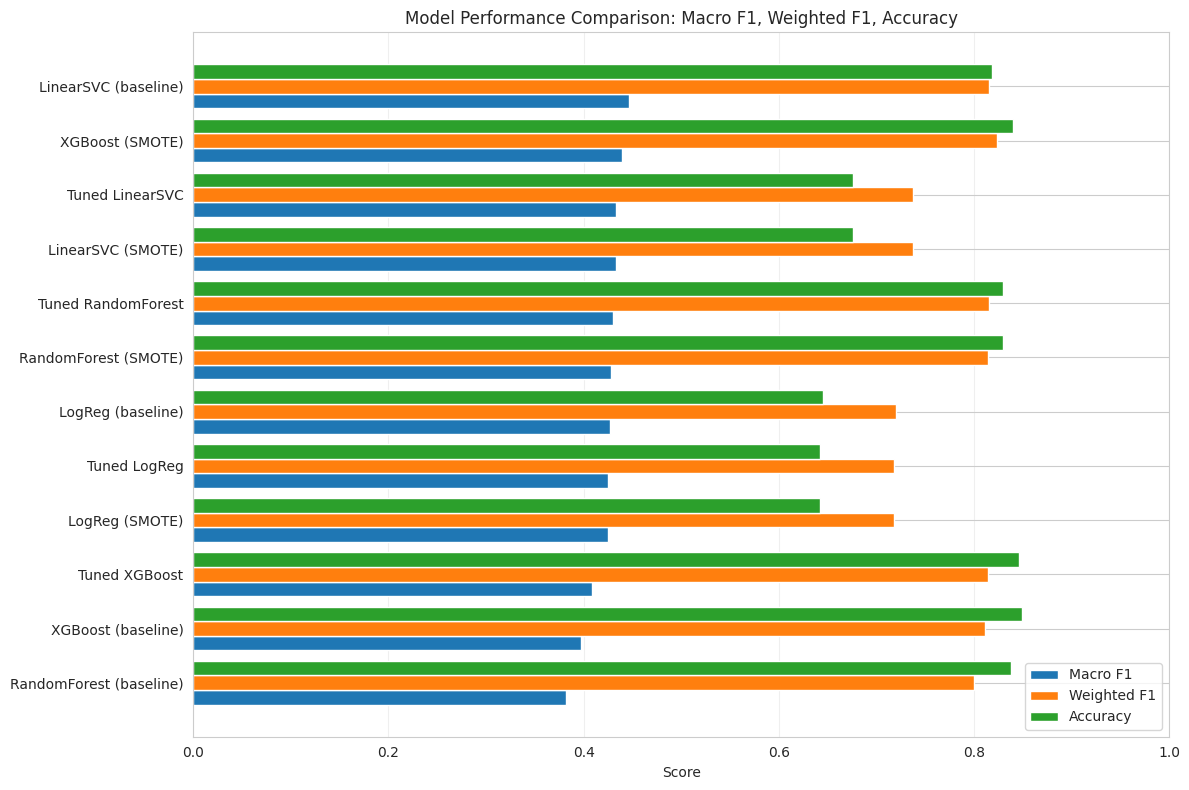

,Model,Macro F1,Weighted F1,Accuracy
0,RandomForest (baseline),0.3823,0.8001,0.8383
1,XGBoost (baseline),0.3972,0.8110,0.8498
2,Tuned XGBoost,0.4087,0.8140,0.8458
3,LogReg (SMOTE),0.4247,0.7184,0.6418
4,Tuned LogReg,0.4247,0.7184,0.6418
5,LogReg (baseline),0.4269,0.7206,0.6458
6,RandomForest (SMOTE),0.4282,0.8144,0.8294
7,Tuned RandomForest,0.4299,0.8155,0.8303
8,LinearSVC (SMOTE),0.4333,0.7378,0.6765
9,Tuned LinearSVC,0.4333,0.7378,0.6765


In [34]:
avg_df = pd.DataFrame([{
    'Model': r['Model'],
    'Macro F1':    r['F1 (macro)'],
    'Weighted F1': r['F1 (weighted)'],
    'Accuracy':    r['Accuracy'],
} for r in baseline_results + smote_results + final_results])
avg_df = avg_df.sort_values('Macro F1', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(avg_df))
w = 0.27
ax.barh(y_pos - w, avg_df['Macro F1'],    height=w, label='Macro F1',    color='#1f77b4')
ax.barh(y_pos,     avg_df['Weighted F1'], height=w, label='Weighted F1', color='#ff7f0e')
ax.barh(y_pos + w, avg_df['Accuracy'],    height=w, label='Accuracy',    color='#2ca02c')
ax.set_yticks(y_pos); ax.set_yticklabels(avg_df['Model'])
ax.set_xlabel('Score'); ax.set_xlim(0, 1)
ax.set_title('Model Performance Comparison: Macro F1, Weighted F1, Accuracy')
ax.legend(loc='lower right'); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_macro_weighted_comparison.png', dpi=800, bbox_inches='tight')
plt.show()
avg_df.round(4)


## 19. Training vs Test Confusion Matrices — Best Models

Side-by-side confusion matrices on the un-resampled training set vs. the held-out test set, for both winners. This visualizes the train-to-test gap directly:

- LinearSVC: similar errors on train and test → at capacity ceiling, not overfitting.
- XGBoost: classifies prediabetes well on training but loses this on test → mild overfitting (matches the loss curve in Section 12).

In [35]:
# Print classification reports on the un-resampled training set so the
# overfitting story is quantified, then plot the side-by-side CMs.
top_two = [best_by_f1]
if best_by_acc != best_by_f1:
    top_two.append(best_by_acc)

print('--- Training-set classification reports (un-resampled) ---')
for name in top_two:
    print(f'\n=== {name} - Training set ===')
    y_tr_pred = best_models[name].predict(X_train_scaled)
    print(classification_report(
        y_train, y_tr_pred, digits=4, zero_division=0,
        target_names=['No Diabetes', 'Prediabetes', 'Diabetes']
    ))


--- Training-set classification reports (un-resampled) ---

=== LinearSVC - Training set ===
              precision    recall  f1-score   support

 No Diabetes     0.9440    0.6964    0.8015    170962
 Prediabetes     0.0322    0.2329    0.0566      3705
    Diabetes     0.3477    0.6150    0.4442     28277

    accuracy                         0.6766    202944
   macro avg     0.4413    0.5147    0.4341    202944
weighted avg     0.8443    0.6766    0.7381    202944


=== XGBoost - Training set ===
              precision    recall  f1-score   support

 No Diabetes     0.8852    0.9804    0.9303    170962
 Prediabetes     0.9669    0.0394    0.0757      3705
    Diabetes     0.7408    0.3521    0.4773     28277

    accuracy                         0.8757    202944
   macro avg     0.8643    0.4573    0.4945    202944
weighted avg     0.8665    0.8757    0.8516    202944



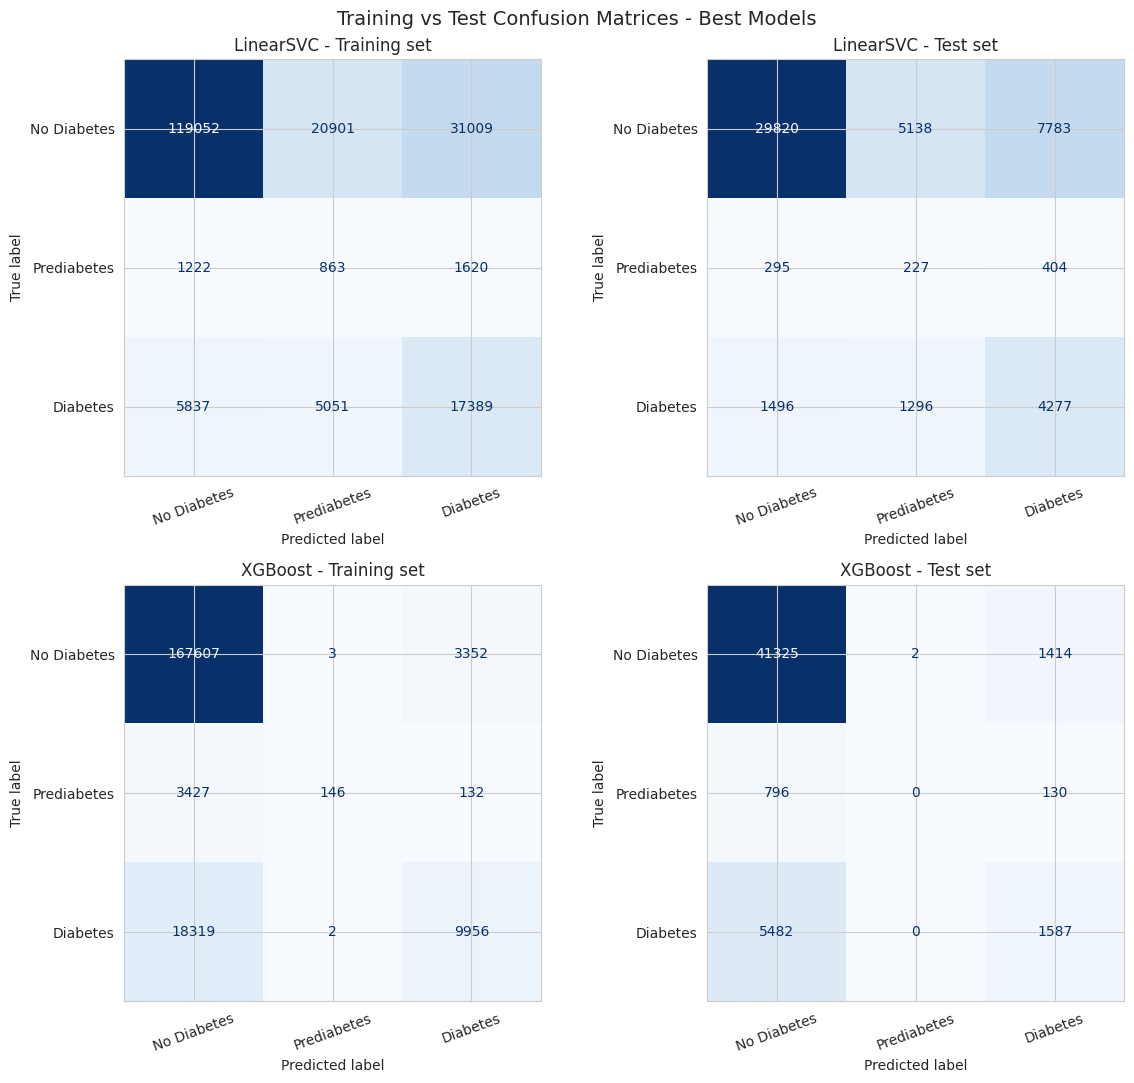

In [36]:
# Side-by-side train vs test confusion matrices
fig, axes = plt.subplots(len(top_two), 2, figsize=(12, 5.5 * len(top_two)))
if len(top_two) == 1:
    axes = axes.reshape(1, 2)
labels = ['No Diabetes', 'Prediabetes', 'Diabetes']

for row, name in enumerate(top_two):
    mdl = best_models[name]
    y_tr_pred = mdl.predict(X_train_scaled)
    y_te_pred = mdl.predict(X_test_scaled)

    cm_tr = confusion_matrix(y_train, y_tr_pred)
    cm_te = confusion_matrix(y_test,  y_te_pred)

    ConfusionMatrixDisplay(cm_tr, display_labels=labels).plot(
        ax=axes[row, 0], cmap='Blues', values_format='d', colorbar=False)
    axes[row, 0].set_title(f'{name} - Training set', fontsize=12)
    axes[row, 0].set_xticklabels(labels, rotation=20)

    ConfusionMatrixDisplay(cm_te, display_labels=labels).plot(
        ax=axes[row, 1], cmap='Blues', values_format='d', colorbar=False)
    axes[row, 1].set_title(f'{name} - Test set', fontsize=12)
    axes[row, 1].set_xticklabels(labels, rotation=20)

plt.suptitle('Training vs Test Confusion Matrices - Best Models', fontsize=14)
plt.tight_layout()
plt.savefig('fig_train_test_cm.png', dpi=800, bbox_inches='tight')
plt.show()


## 20. Final Summary — All Approaches

Combined comparison table of every baseline, SMOTE, and tuned configuration. This is the table that goes in the report.

In [37]:
summary = pd.DataFrame(baseline_results + smote_results + final_results)
summary = summary.round(4)
print('=== Full Model Comparison ===')
summary


=== Full Model Comparison ===


,Model,Accuracy,Precision (w),Recall (w),F1 (weighted),F1 (macro)
0,LogReg (baseline),0.6458,0.8510,0.6458,0.7206,0.4269
1,RandomForest (baseline),0.8383,0.7889,0.8383,0.8001,0.3823
2,LinearSVC (baseline),0.8185,0.8151,0.8185,0.8159,0.4467
3,XGBoost (baseline),0.8498,0.8056,0.8498,0.8110,0.3972
4,LogReg (SMOTE),0.6418,0.8507,0.6418,0.7184,0.4247
5,RandomForest (SMOTE),0.8294,0.8021,0.8294,0.8144,0.4282
6,LinearSVC (SMOTE),0.6765,0.8431,0.6765,0.7378,0.4333
7,XGBoost (SMOTE),0.8400,0.8103,0.8400,0.8235,0.4390
8,Tuned LogReg,0.6418,0.8507,0.6418,0.7184,0.4247
9,Tuned RandomForest,0.8303,0.8033,0.8303,0.8155,0.4299


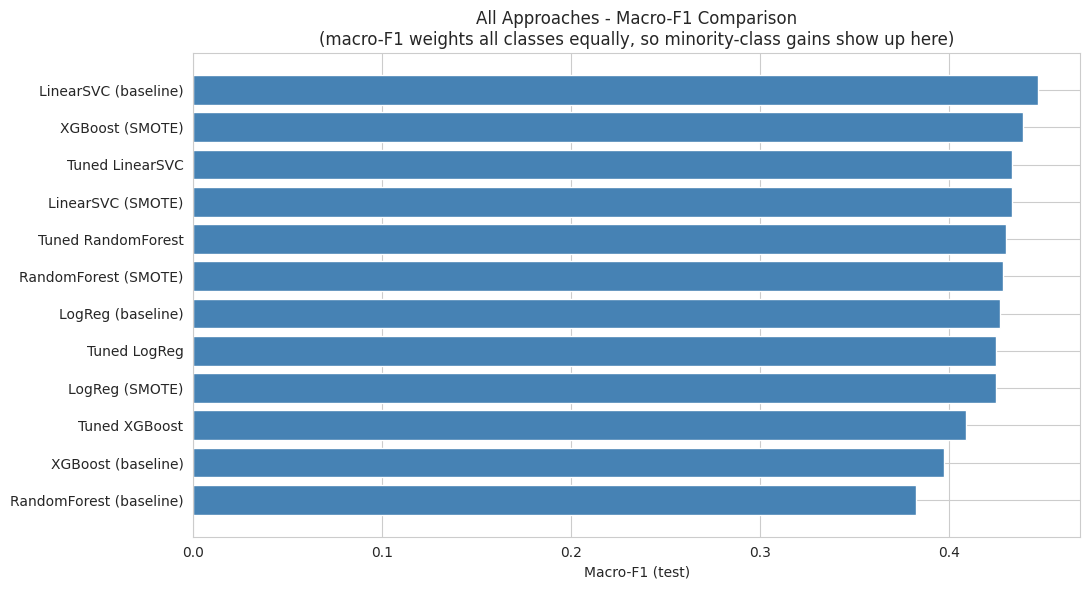

In [38]:
# Macro-F1 bar chart - the primary metric for an imbalanced screening task
plt.figure(figsize=(11, 6))
order = summary.sort_values('F1 (macro)', ascending=True)
plt.barh(order['Model'], order['F1 (macro)'], color='steelblue')
plt.xlabel('Macro-F1 (test)')
plt.title('All Approaches - Macro-F1 Comparison\n'
          '(macro-F1 weights all classes equally, so minority-class gains show up here)')
plt.tight_layout()
plt.savefig('fig_final_comparison.png', dpi=800, bbox_inches='tight')
plt.show()


In [39]:
# Save the summary table to CSV for the report
summary.to_csv('results_summary.csv', index=False)
print('Saved: results_summary.csv')
print()
print('All figures generated in this notebook:')
import glob
for f in sorted(glob.glob('fig_*.png')):
    print(f'  {f}')


Saved: results_summary.csv

All figures generated in this notebook:
  fig_boxplots.png
  fig_class_distribution.png
  fig_confusion_matrices.png
  fig_correlation.png
  fig_final_comparison.png
  fig_histograms.png
  fig_learning_curve_acc.png
  fig_learning_curve_f1.png
  fig_loss_curve.png
  fig_macro_weighted_comparison.png
  fig_pipeline.png
  fig_prf_comparison.png
  fig_rf_importance.png
  fig_roc_acc.png
  fig_roc_f1.png
  fig_shap.png
  fig_svc_coefficients.png
  fig_train_test_cm.png
  fig_xgb_importance.png
